<a href="https://colab.research.google.com/github/ard0p8v/KSU2_HierarchicalWeatherForecasting/blob/main/weather_hierarchy_forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Zápočtový úkol 1 - Predikce z hierarchických dat
**Předmět:** Strojové učení II (KSU2)  
**Autor:** Bc. Pavel Ardolf  
**GitHub Repozitář:** https://github.com/ard0p8v/KSU2_HierarchicalWeatherForecasting

---

## 1. Cíl projektu
Cílem práce je implementovat a porovnat dvě základní metody předpovídání na hierarchicky uspořádaných datech: **Bottom-Up** a **Top-Down**.[1] Projekt demonstruje schopnost pracovat s daty, která jsou vzájemně provázána v logické stromové struktuře a vyžadují specifické metody rekonciliace pro zajištění koherence napříč úrovněmi.[3]

## 2. Popis hierarchie a dat
Pro projekt byla zvolena meteorologická data (teplota), která tvoří tříúrovňovou hierarchii:[1]
* **Úroveň 0 (Top):** Kontinent (Evropa) – agregovaný průměr ze všech sledovaných států.
* **Úroveň 1 (Middle):** Státy (CZ, AT, DE, PL, SK) – průměr z vybraných měst v dané zemi.
* **Úroveň 2 (Bottom):** Města (např. Praha, Brno, Vídeň, Berlín atd.) – primární zdroj dat.

**Datový zdroj:** Historické záznamy byly staženy pomocí Open-Meteo API [5] za období 2019–2023. Celkem dataset obsahuje denní záznamy pro více než 20 evropských měst.

## 3. Metodika
V notebooku jsou realizovány kroky v souladu s osvědčenými postupy pro analýzu časových řad:[1][2]
1. **Příprava dat:** Načtení CSV souborů a kontrola koherence hierarchie.
2. **Exploratory Data Analysis (EDA):** Vizualizace historických trendů a sezónnosti.
3. **Modelování:**
   - **Bottom-Up:** Trénování modelu **Prophet** [4] pro každé město a následná agregace výsledků nahoru.
   - **Top-Down:** Předpověď pro kontinent a následná distribuce (disagregace) směrem dolů pomocí historických proporcí.
4. **Evaluace:** Porovnání přesnosti metod pomocí metrik MAE, RMSE a R².

In [11]:
"""
Obsah skriptu:
- Stahování dat z Open-Meteo API
- Agregace měst do států a států do kontinentu
- Kontrola integrity hierarchie
"""
!pip install openmeteo-requests requests-cache retry-requests
import openmeteo_requests
import requests_cache
from retry_requests import retry
import pandas as pd
import numpy as np
import os

# Init konfigurace
START_DATE = "2019-01-01"
END_DATE   = "2023-12-31"
OUTPUT_DIR = "data"

# Hierarchická struktura - kontinent → stát → město → lat, lon
CITIES = {
    "CZ": {
        "Praha":          (50.0755, 14.4378),
        "Brno":           (49.1951, 16.6068),
        "Ostrava":        (49.8209, 18.2625),
        "Hradec Králové": (50.2092, 15.8328),
        "Plzeň":          (49.7384, 13.3736),
        "Liberec":        (50.7663, 15.0543),
    },
    "DE": {
        "Berlín":   (52.5200, 13.4050),
        "Mnichov":  (48.1351, 11.5820),
        "Hamburg":  (53.5753, 10.0153),
        "Frankfurt":(50.1109, 8.6821),
    },
    "AT": {
        "Vídeň":    (48.2082, 16.3738),
        "Salzburg": (47.8095, 13.0550),
        "Innsbruck":(47.2692, 11.4041),
    },
    "PL": {
        "Varšava": (52.2297, 21.0122),
        "Krakov":  (50.0647, 19.9450),
        "Wrocław": (51.1079, 17.0385),
    },
    "SK": {
        "Bratislava": (48.1486, 17.1077),
        "Košice":     (48.7164, 21.2611),
    },
}

# Stažení dat
def download_all(cities: dict, start: str, end: str) -> pd.DataFrame:
    cache_session = requests_cache.CachedSession(".om_cache", expire_after=-1)
    retry_session = retry(cache_session, retries=5, backoff_factor=0.3)
    client = openmeteo_requests.Client(session=retry_session)

    records = []
    total = sum(len(v) for v in cities.values())
    done = 0

    import time

    for country, city_dict in cities.items():
        for city, (lat, lon) in city_dict.items():
            done += 1
            print(f"  [{done}/{total}] {city} ({country})...", end=" ", flush=True)

            params = {
                "latitude":   lat,
                "longitude":  lon,
                "daily":      [
                    "temperature_2m_max",
                    "temperature_2m_min",
                    "precipitation_sum",
                ],
                "start_date": start,
                "end_date":   end,
                "timezone":   "Europe/Prague",
            }

            try:
                resp = client.weather_api(
                    "https://archive-api.open-meteo.com/v1/archive",
                    params=params
                )
            except Exception as e:
                print(f"CHYBA: {e} — čekám 60s a zkouším znovu...")
                time.sleep(60)
                resp = client.weather_api(
                    "https://archive-api.open-meteo.com/v1/archive",
                    params=params
                )

            r = resp[0]
            daily = r.Daily()

            dates = pd.date_range(
                start=pd.to_datetime(daily.Time(), unit="s", utc=True),
                end=pd.to_datetime(daily.TimeEnd(), unit="s", utc=True),
                freq=pd.Timedelta(seconds=daily.Interval()),
                inclusive="left",
            )

            df = pd.DataFrame({
                "date":        dates,
                "continent":   "Evropa",
                "country":     country,
                "city":        city,
                "temp_max":    daily.Variables(0).ValuesAsNumpy(),
                "temp_min":    daily.Variables(1).ValuesAsNumpy(),
                "precip_sum":  daily.Variables(2).ValuesAsNumpy(),
            })
            df["temp_mean"] = (df["temp_max"] + df["temp_min"]) / 2.0
            records.append(df)
            print("OK")

            time.sleep(2)

    df_all = pd.concat(records, ignore_index=True)
    df_all["date"] = df_all["date"].dt.tz_localize(None)
    return df_all


# Agregace na vyšší úrovně hierarchie
def build_hierarchy(df: pd.DataFrame) -> dict[str, pd.DataFrame]:
    """
    Vrátí slovník DataFramů pro každou úroveň hierarchie.

    Úroveň 0 – Evropa (průměr přes všechna města)
    Úroveň 1 – Stát   (průměr přes města v dané zemi)
    Úroveň 2 – Město  (raw data)
    """
    grp = ["date"]

    level_city = df.copy()

    level_country = (
        df.groupby(["date", "continent", "country"], as_index=False)
        .agg(
            temp_max=("temp_max", "mean"),
            temp_min=("temp_min", "mean"),
            temp_mean=("temp_mean", "mean"),
            precip_sum=("precip_sum", "mean"),
        )
    )

    level_continent = (
        level_country.groupby(["date", "continent"], as_index=False)
        .agg(
            temp_max=("temp_max", "mean"),
            temp_min=("temp_min", "mean"),
            temp_mean=("temp_mean", "mean"),
            precip_sum=("precip_sum", "mean"),
        )
    )

    return {
        "city":      level_city,
        "country":   level_country,
        "continent": level_continent,
    }


# Rychlá EDA
def print_eda(hierarchy: dict):
    print("\n" + "="*60)
    print("PŘEHLED DATASETU")
    print("="*60)

    for level, df in hierarchy.items():
        print(f"\n── Úroveň: {level.upper()} ──")
        print(f"   Řádků:       {len(df):,}")
        print(f"   Sloupců:     {list(df.columns)}")
        if "city" in df.columns:
            print(f"   Měst:        {df['city'].nunique()}")
        if "country" in df.columns:
            print(f"   Zemí:        {df['country'].nunique()}")
        print(f"   Chybějící:   {df.isnull().sum().to_dict()}")
        print(f"   Temp_mean:   {df['temp_mean'].min():.1f} – {df['temp_mean'].max():.1f} °C")
        print(f"   Precip_sum:  {df['precip_sum'].min():.1f} – {df['precip_sum'].max():.1f} mm")

    print("\n── KOHERENCE HIERARCHIE ──")
    city_df    = hierarchy["city"]
    country_df = hierarchy["country"]

    check = (
        city_df.groupby(["date", "country"])["temp_mean"].mean()
        .reset_index()
        .merge(country_df[["date", "country", "temp_mean"]], on=["date", "country"])
    )
    max_diff = (check["temp_mean_x"] - check["temp_mean_y"]).abs().max()
    print(f"   Max. odchylka město→stát: {max_diff:.6f} °C (ideálně < 0.001)")


# Uložení
def save(hierarchy: dict, output_dir: str):
    os.makedirs(output_dir, exist_ok=True)
    for level, df in hierarchy.items():
        path = os.path.join(output_dir, f"weather_{level}.csv")
        df.to_csv(path, index=False)
        print(f"   Uloženo: {path}  ({len(df):,} řádků)")

if __name__ == "__main__":
    print("=" * 60)
    print("STAHOVÁNÍ DAT Z OPEN-METEO")
    print(f"Období: {START_DATE} → {END_DATE}")
    print(f"Měst celkem: {sum(len(v) for v in CITIES.values())}")
    print("=" * 60 + "\n")

    # 1. Stažení
    df_raw = download_all(CITIES, START_DATE, END_DATE)
    print(f"\nStaženo celkem: {len(df_raw):,} řádků\n")

    # 2. Sestavení hierarchie
    print("Sestavuji hierarchii...")
    hierarchy = build_hierarchy(df_raw)

    # 3. EDA
    print_eda(hierarchy)

    # 4. Uložení
    print("\nUkládám soubory...")
    save(hierarchy, OUTPUT_DIR)

    print("\nHotovo! Soubory jsou v adresáři ./data/")
    print("  weather_city.csv      — úroveň město (nejnižší)")
    print("  weather_country.csv   — úroveň stát")
    print("  weather_continent.csv — úroveň kontinent (nejvyšší)")


STAHOVÁNÍ DAT Z OPEN-METEO
Období: 2019-01-01 → 2023-12-31
Měst celkem: 18

  [1/18] Praha (CZ)... OK
  [2/18] Brno (CZ)... OK
  [3/18] Ostrava (CZ)... OK
  [4/18] Hradec Králové (CZ)... OK
  [5/18] Plzeň (CZ)... OK
  [6/18] Liberec (CZ)... OK
  [7/18] Berlín (DE)... OK
  [8/18] Mnichov (DE)... OK
  [9/18] Hamburg (DE)... OK
  [10/18] Frankfurt (DE)... OK
  [11/18] Vídeň (AT)... OK
  [12/18] Salzburg (AT)... OK
  [13/18] Innsbruck (AT)... OK
  [14/18] Varšava (PL)... OK
  [15/18] Krakov (PL)... OK
  [16/18] Wrocław (PL)... OK
  [17/18] Bratislava (SK)... OK
  [18/18] Košice (SK)... OK

Staženo celkem: 32,868 řádků

Sestavuji hierarchii...

PŘEHLED DATASETU

── Úroveň: CITY ──
   Řádků:       32,868
   Sloupců:     ['date', 'continent', 'country', 'city', 'temp_max', 'temp_min', 'precip_sum', 'temp_mean']
   Měst:        18
   Zemí:        5
   Chybějící:   {'date': 0, 'continent': 0, 'country': 0, 'city': 0, 'temp_max': 0, 'temp_min': 0, 'precip_sum': 0, 'temp_mean': 0}
   Temp_mean:  

In [12]:
!pip install prophet

import os
import pandas as pd

# Vytvoření složky data, pokud neexistuje
os.makedirs('data', exist_ok=True)

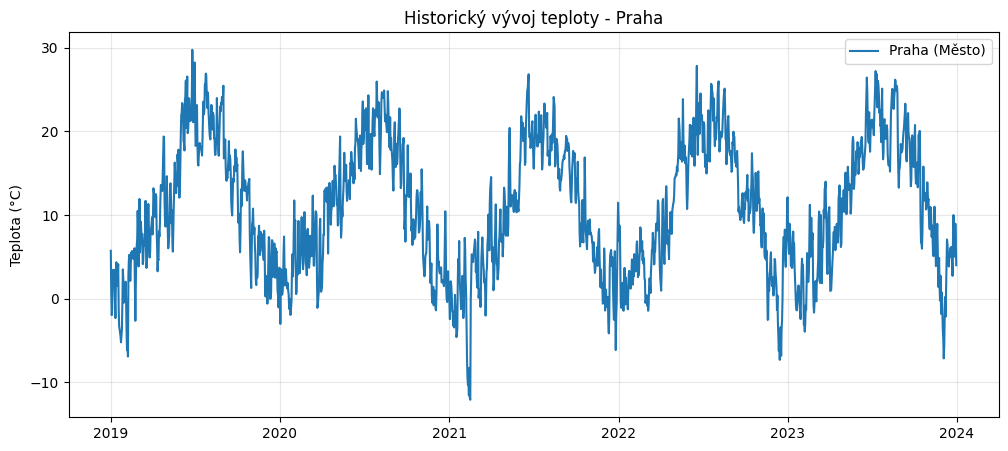

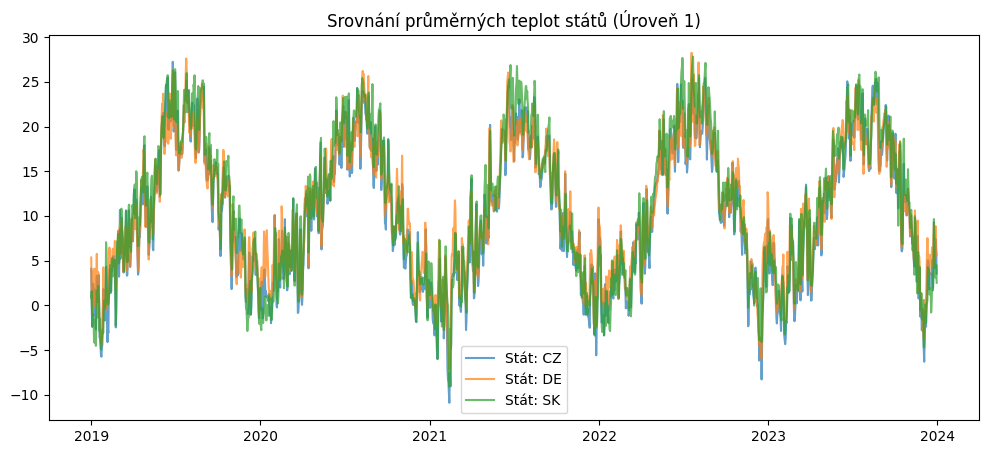

Souhrnné statistiky pro úroveň států:
          count       mean       std        min       25%        50%  \
country                                                                
AT       1826.0  11.141549  7.460070  -6.018833  4.877000  10.897834   
CZ       1826.0  10.211253  7.694444 -10.891583  3.806333   9.933416   
DE       1826.0  10.807753  7.084314  -7.150000  5.084375  10.415624   
PL       1826.0  10.360113  7.882208 -13.050000  3.925000  10.066667   
SK       1826.0  11.156743  8.163684  -9.087500  4.050000  11.125000   

               75%        max  
country                        
AT       17.560333  26.889502  
CZ       16.796958  27.233416  
DE       17.035937  28.243752  
PL       17.041666  27.600000  
SK       18.337500  27.812500  


In [13]:
import matplotlib.pyplot as plt

# Načtení dat pro vizualizaci
city_df = pd.read_csv('data/weather_city.csv', parse_dates=['date'])
country_df = pd.read_csv('data/weather_country.csv', parse_dates=['date'])

# Vizualizace trendu na úrovni města (Praha)
plt.figure(figsize=(12, 5))
plt.plot(city_df[city_df['city'] == 'Praha']['date'],
         city_df[city_df['city'] == 'Praha']['temp_mean'], label='Praha (Město)')
plt.title('Historický vývoj teploty - Praha')
plt.ylabel('Teplota (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Porovnání států
plt.figure(figsize=(12, 5))
for country in ['CZ', 'DE', 'SK']:
    subset = country_df[country_df['country'] == country]
    plt.plot(subset['date'], subset['temp_mean'], label=f'Stát: {country}', alpha=0.7)
plt.title('Srovnání průměrných teplot států (Úroveň 1)')
plt.legend()
plt.show()

# Souhrnné statistiky
print("Souhrnné statistiky pro úroveň států:")
print(country_df.groupby('country')['temp_mean'].describe())

HIERARCHICKÉ PŘEDPOVÍDÁNÍ TEPLOTY

[Bottom-Up] Trénovám modely pro každé město...
  [1/18] Praha
  [2/18] Brno
  [3/18] Ostrava
  [4/18] Hradec Králové
  [5/18] Plzeň
  [6/18] Liberec
  [7/18] Berlín
  [8/18] Mnichov
  [9/18] Hamburg
  [10/18] Frankfurt
  [11/18] Vídeň
  [12/18] Salzburg
  [13/18] Innsbruck
  [14/18] Varšava
  [15/18] Krakov
  [16/18] Wrocław
  [17/18] Bratislava
  [18/18] Košice

[Top-Down] Trénovám model na úrovni Evropy...

[Vyhodnocení]
  Skutečnost continent: 2023-01-01 — 2023-12-30, řádků: 364
  BU predikce continent: 2023-01-01 — 2023-12-31, řádků: 365
  [continent] průnik: 364 řádků
  [country] průnik: 1820 řádků
  [city] průnik: 6552 řádků
  [continent] průnik: 364 řádků
  [country] průnik: 1820 řádků
  [city] průnik: 6552 řádků
   Metoda    Úroveň   MAE  RMSE    R2
Bottom-Up continent 2.378 2.909 0.853
Bottom-Up   country 2.618 3.174 0.829
Bottom-Up      city 2.770 3.381 0.809
 Top-Down continent 2.381 2.912 0.853
 Top-Down   country 2.582 3.147 0.832
 Top-Do

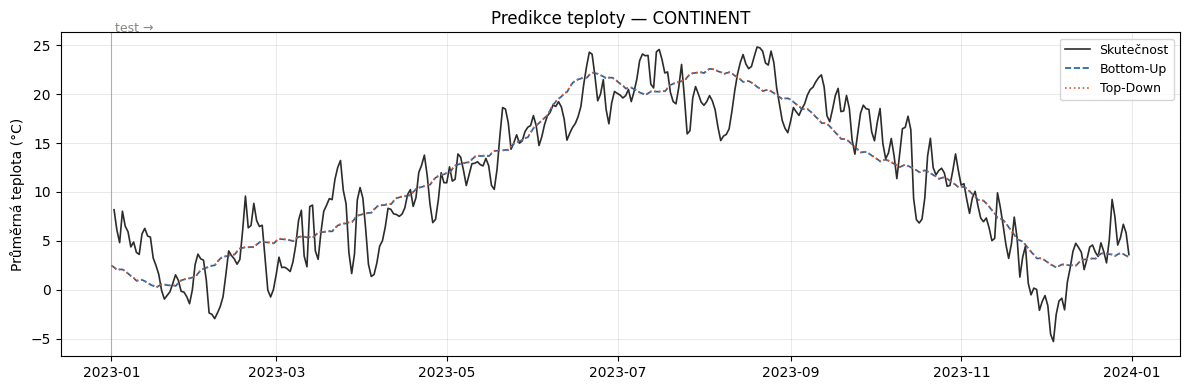

  Graf uložen: output/forecast_continent.png


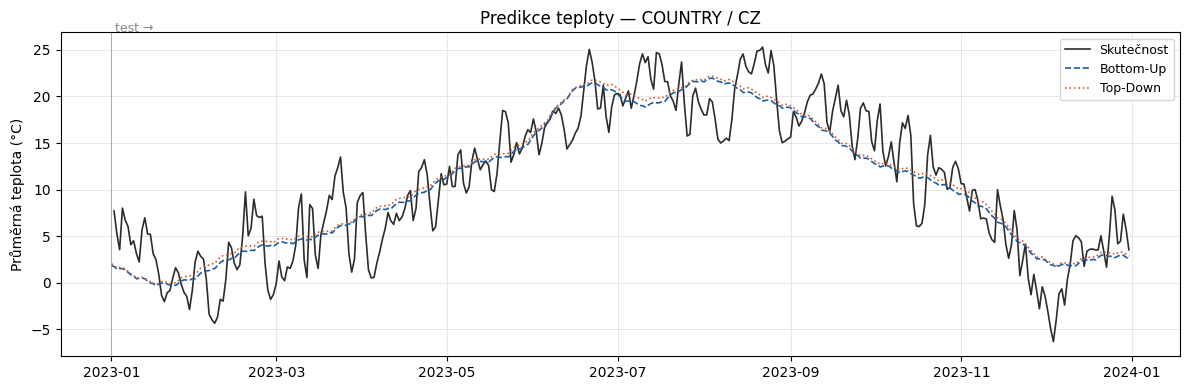

  Graf uložen: output/forecast_country_CZ.png


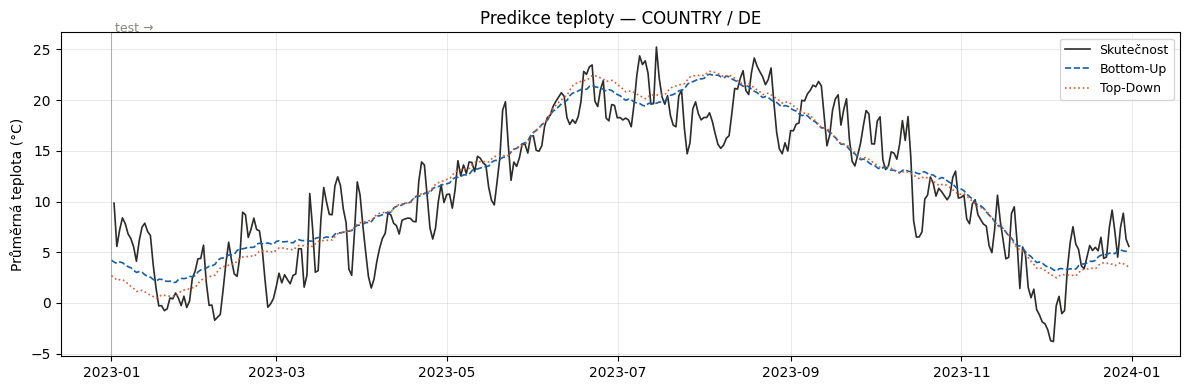

  Graf uložen: output/forecast_country_DE.png


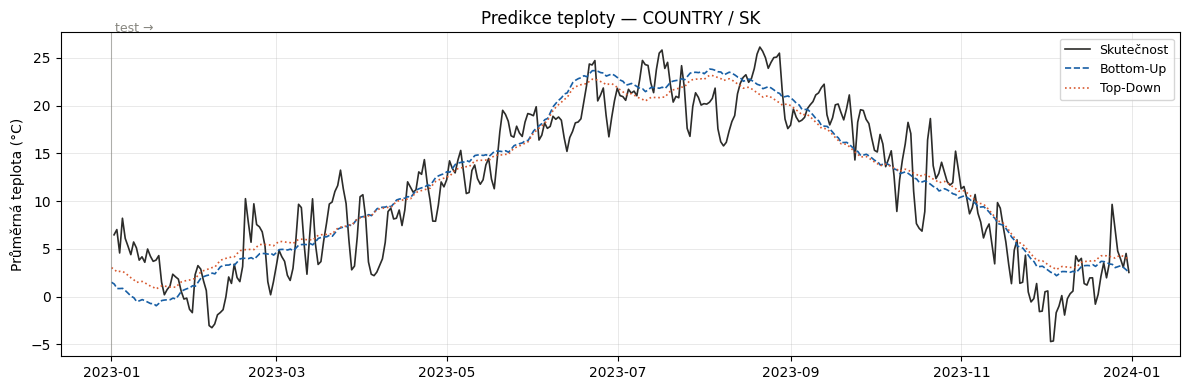

  Graf uložen: output/forecast_country_SK.png


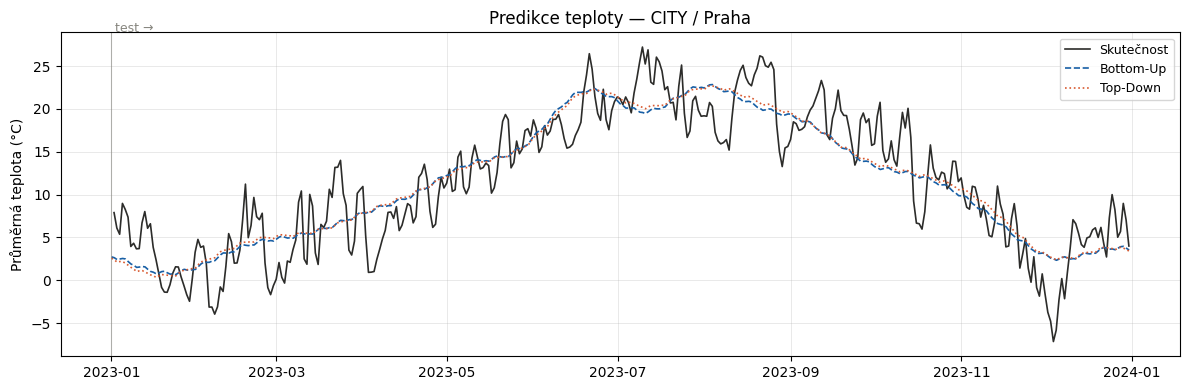

  Graf uložen: output/forecast_city_Praha.png


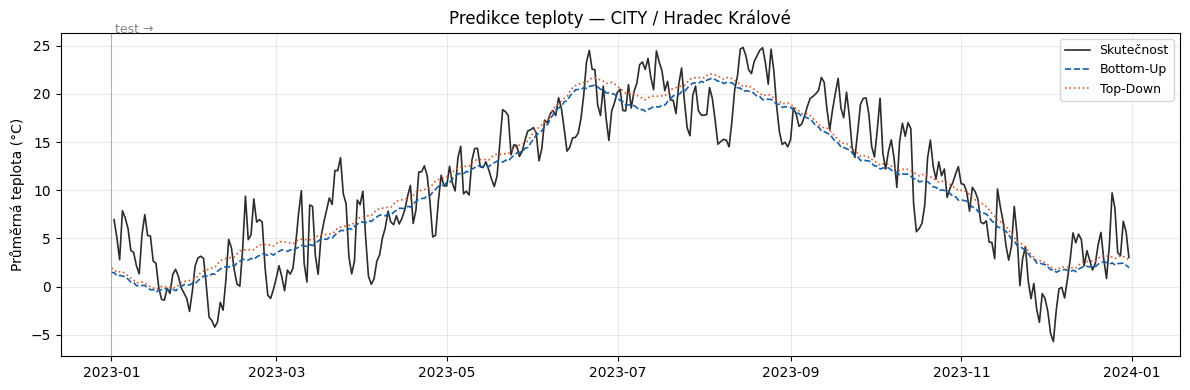

  Graf uložen: output/forecast_city_Hradec Králové.png


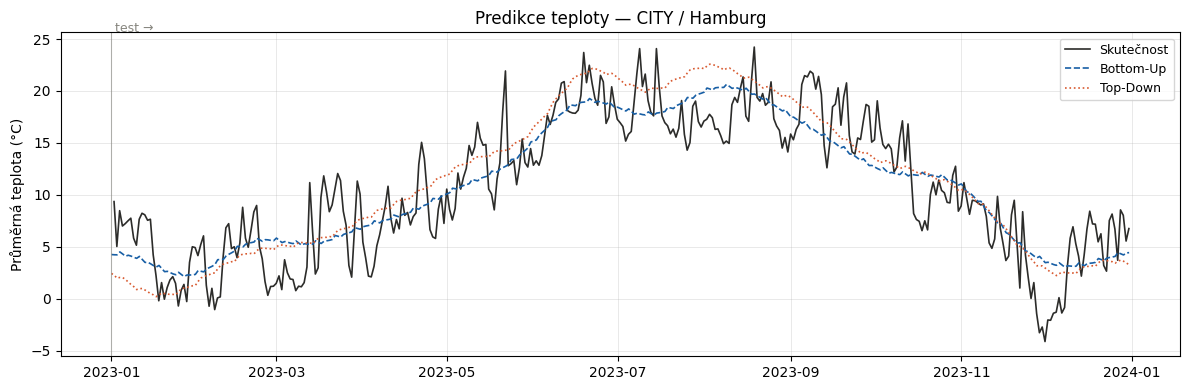

  Graf uložen: output/forecast_city_Hamburg.png


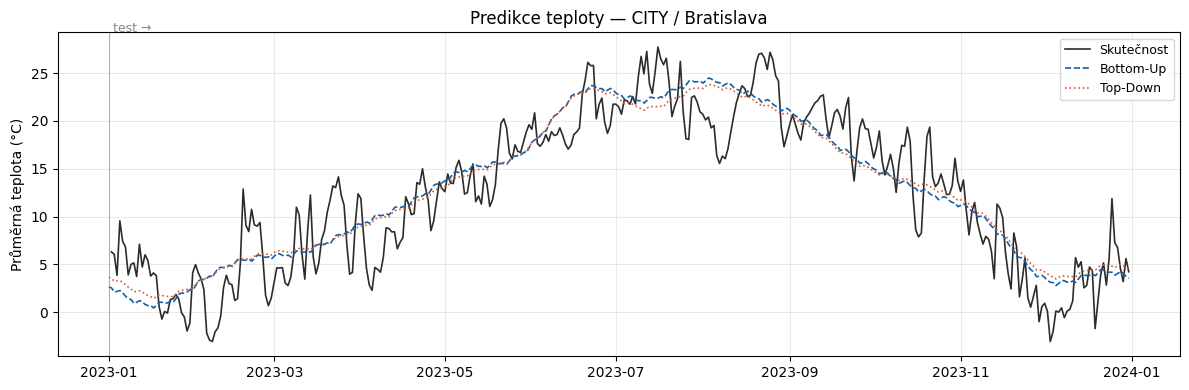

  Graf uložen: output/forecast_city_Bratislava.png

Hotovo! Výsledky jsou v adresáři ./output/
  metrics.csv              — MAE a RMSE pro každou metodu a úroveň
  forecast_continent.png   — srovnání na úrovni Evropy
  forecast_country_CZ.png  — srovnání pro Českou republiku
  forecast_city_Praha.png  — srovnání pro Prahu


In [14]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Init konfigurace
DATA_DIR      = Path("data")
OUTPUT_DIR    = Path("output")
TRAIN_END     = "2022-12-31"   # trénink na 2019–2022
TEST_START    = "2023-01-01"   # test na 2023
FORECAST_DAYS = 365            # předpovídat celý rok 2023
TARGET        = "temp_mean"    # předpovídaná proměnná

# Načtení dat
def load_data():
    city_df      = pd.read_csv(DATA_DIR / "weather_city.csv",      parse_dates=["date"])
    country_df   = pd.read_csv(DATA_DIR / "weather_country.csv",   parse_dates=["date"])
    continent_df = pd.read_csv(DATA_DIR / "weather_continent.csv", parse_dates=["date"])
    return city_df, country_df, continent_df


# Prophet helper
def prophet_forecast(series: pd.Series, dates: pd.Series, future_dates: pd.DatetimeIndex) -> np.ndarray:
    """
    Natrénuje Prophet model na (dates, series) a vrátí predikce pro future_dates.
    Vrací numpy array ve stejném pořadí jako future_dates.
    """
    from prophet import Prophet

    df_train = pd.DataFrame({"ds": dates, "y": series})
    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode="additive",
        changepoint_prior_scale=0.05,
    )
    m.fit(df_train, iter=300)

    future = pd.DataFrame({"ds": future_dates})
    forecast = m.predict(future)
    return forecast["yhat"].values


# METODA 1: Bottom-Up
def method_bottomup(city_df: pd.DataFrame, future_dates: pd.DatetimeIndex) -> dict:
    """
    1. Natrénuj Prophet pro každé město zvlášť na trénovacích datech.
    2. Predikuj teplotu pro každé město na testovacím období.
    3. Agreguj predikce nahoru: průměr přes města → stát, průměr přes státy → Evropa.
    """
    print("\n[Bottom-Up] Trénovám modely pro každé město...")
    cities = city_df["city"].unique()
    train  = city_df[city_df["date"] <= TRAIN_END]

    city_preds = {}
    for i, city in enumerate(cities, 1):
        print(f"  [{i}/{len(cities)}] {city}")
        sub = train[train["city"] == city].sort_values("date")
        preds = prophet_forecast(sub[TARGET], sub["date"], future_dates)
        city_preds[city] = preds

    # Sestavení DataFramu predikcí na úrovni měst
    city_meta = city_df[["city", "country", "continent"]].drop_duplicates()
    pred_city_df = pd.DataFrame({
        "date": np.tile(future_dates, len(cities)),
        "city": np.repeat(cities, len(future_dates)),
        TARGET: np.concatenate([city_preds[c] for c in cities]),
    }).merge(city_meta, on="city")

    # Agregace - stát
    pred_country_df = (
        pred_city_df.groupby(["date", "continent", "country"])[TARGET]
        .mean().reset_index()
    )

    # Agregace - Evropa
    pred_continent_df = (
        pred_country_df.groupby(["date", "continent"])[TARGET]
        .mean().reset_index()
    )

    return {
        "city":      pred_city_df,
        "country":   pred_country_df,
        "continent": pred_continent_df,
    }


# METODA 2: Top-Down (Average Historical Proportions)
def method_topdown(city_df: pd.DataFrame, continent_df: pd.DataFrame,
                   future_dates: pd.DatetimeIndex) -> dict:
    """
    1. Natrénuj Prophet na kontinentální úrovni.
    2. Předpovídej celkovou teplotu Evropy.
    3. Rozděl predikce dolů pomocí historických podílů každého města/státu.

    Historický podíl města i: p_i = mean(y_i) / mean(y_total)
    Predikce města i: ŷ_i = p_i * ŷ_total

    Poznámka: pro teplotu (interval, ne součet) je podíl spočítán
    jako odchylka od průměru Evropy: offset_i = mean(y_i - y_europe).
    Predikce: ŷ_i = ŷ_europe + offset_i
    """
    print("\n[Top-Down] Trénovám model na úrovni Evropy...")
    train_cont = continent_df[continent_df["date"] <= TRAIN_END].sort_values("date")
    cont_preds = prophet_forecast(train_cont[TARGET], train_cont["date"], future_dates)
    pred_cont_df = pd.DataFrame({
        "date": future_dates,
        "continent": "Evropa",
        TARGET: cont_preds,
    })

    # Výpočet historických offsetů: o_i = mean(T_city_i) - mean(T_europe)
    train_city = city_df[city_df["date"] <= TRAIN_END]
    europe_mean = train_city.groupby("date")[TARGET].mean().mean()
    city_offsets = (
        train_city.groupby("city")[TARGET].mean() - europe_mean
    )

    city_meta = city_df[["city", "country", "continent"]].drop_duplicates()
    cities = city_meta["city"].tolist()

    # Disagregace - město
    pred_city_rows = []
    for city in cities:
        offset = city_offsets.get(city, 0.0)
        pred_city_rows.append(pd.DataFrame({
            "date": future_dates,
            "city": city,
            TARGET: cont_preds + offset,
        }))
    pred_city_df = pd.concat(pred_city_rows).merge(city_meta, on="city")

    # Agregace - stát (z disagregovaných měst)
    pred_country_df = (
        pred_city_df.groupby(["date", "continent", "country"])[TARGET]
        .mean().reset_index()
    )

    return {
        "city":      pred_city_df,
        "country":   pred_country_df,
        "continent": pred_cont_df,
    }


# Vyhodnocení
def evaluate(actual_dict: dict, pred_dict: dict, method_name: str) -> pd.DataFrame:
    from sklearn.metrics import r2_score
    rows = []
    for level in ["continent", "country", "city"]:
        act_df = actual_dict[level].copy()
        prd_df = pred_dict[level].copy()

        # Normalizace datumu — odstranit čas i timezone
        act_df["date"] = pd.to_datetime(act_df["date"]).dt.normalize()
        prd_df["date"] = pd.to_datetime(prd_df["date"]).dt.normalize()

        if level == "continent":
            merged = act_df[["date", TARGET]].merge(
                prd_df[["date", TARGET]], on="date", suffixes=("_act", "_pred")
            )
        elif level == "country":
            merged = act_df[["date", "country", TARGET]].merge(
                prd_df[["date", "country", TARGET]], on=["date", "country"], suffixes=("_act", "_pred")
            )
        elif level == "city":
            merged = act_df[["date", "city", TARGET]].merge(
                prd_df[["date", "city", TARGET]], on=["date", "city"], suffixes=("_act", "_pred")
            )

        print(f"  [{level}] průnik: {len(merged)} řádků")

        if len(merged) == 0:
            print(f"  VAROVÁNÍ: prázdný průnik pro úroveň {level}!")
            continue

        a = merged[f"{TARGET}_act"].values
        p = merged[f"{TARGET}_pred"].values

        mae  = mean_absolute_error(a, p)
        rmse = mean_squared_error(a, p) ** 0.5
        r2   = r2_score(a, p)
        rows.append({
            "Metoda": method_name,
            "Úroveň": level,
            "MAE":  round(mae,  3),
            "RMSE": round(rmse, 3),
            "R2":   round(r2,   3),
        })

    return pd.DataFrame(rows)


# Vizualizace
def plot_comparison(actual_dict, bu_dict, td_dict, level: str, group: str | None = None):
    OUTPUT_DIR.mkdir(exist_ok=True)

    act_df = actual_dict[level]
    bu_df  = bu_dict[level]
    td_df  = td_dict[level]

    # Filtr pro konkrétní skupinu město/stát
    if group and level == "country":
        act_df = act_df[act_df["country"] == group]
        bu_df  = bu_df[bu_df["country"]  == group]
        td_df  = td_df[td_df["country"]  == group]
    elif group and level == "city":
        act_df = act_df[act_df["city"] == group]
        bu_df  = bu_df[bu_df["city"]   == group]
        td_df  = td_df[td_df["city"]   == group]

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(act_df["date"], act_df[TARGET], label="Skutečnost", color="#2C2C2A", linewidth=1.2)
    ax.plot(bu_df["date"],  bu_df[TARGET],  label="Bottom-Up",  color="#185FA5", linewidth=1.2, linestyle="--")
    ax.plot(td_df["date"],  td_df[TARGET],  label="Top-Down",   color="#D85A30", linewidth=1.2, linestyle=":")
    ax.axvline(pd.Timestamp(TEST_START), color="#888780", linestyle="-", linewidth=0.8, alpha=0.6)
    ax.text(pd.Timestamp(TEST_START), ax.get_ylim()[1], " test →", fontsize=9, color="#888780")
    title = f"Predikce teploty — {level.upper()}" + (f" / {group}" if group else "")
    ax.set_title(title, fontsize=12, fontweight="normal")
    ax.set_ylabel("Průměrná teplota (°C)")
    ax.legend(fontsize=9)
    ax.grid(True, linewidth=0.4, alpha=0.5)
    fig.tight_layout()
    fname = f"forecast_{level}" + (f"_{group}" if group else "") + ".png"
    fig.savefig(OUTPUT_DIR / fname, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"  Graf uložen: {OUTPUT_DIR / fname}")

if __name__ == "__main__":
    print("=" * 60)
    print("HIERARCHICKÉ PŘEDPOVÍDÁNÍ TEPLOTY")
    print("=" * 60)

    # 1. Načtení dat
    city_df, country_df, continent_df = load_data()

    # Testovací skutečná data
    actual = {
        "city":      city_df[city_df["date"] >= TEST_START],
        "country":   country_df[country_df["date"] >= TEST_START],
        "continent": continent_df[continent_df["date"] >= TEST_START],
    }
    future_dates = pd.date_range(TEST_START, periods=FORECAST_DAYS, freq="D")

    # 2. Metoda 1 – Bottom-Up
    bu_preds = method_bottomup(city_df, future_dates)

    # 3. Metoda 2 – Top-Down
    td_preds = method_topdown(city_df, continent_df, future_dates)

    # 4. Vyhodnocení
    print("\n[Vyhodnocení]")
    # Debug: zkontroluj rozsahy dat
    print(f"  Skutečnost continent: {actual['continent']['date'].min().date()} — {actual['continent']['date'].max().date()}, řádků: {len(actual['continent'])}")
    print(f"  BU predikce continent: {bu_preds['continent']['date'].min().date()} — {bu_preds['continent']['date'].max().date()}, řádků: {len(bu_preds['continent'])}")

    metrics_bu = evaluate(actual, bu_preds, "Bottom-Up")
    metrics_td = evaluate(actual, td_preds, "Top-Down")
    metrics_all = pd.concat([metrics_bu, metrics_td])
    print(metrics_all.to_string(index=False))
    OUTPUT_DIR.mkdir(exist_ok=True)
    metrics_all.to_csv(OUTPUT_DIR / "metrics.csv", index=False)

    # 5. Grafy
    print("\n[Grafy]")
    plot_comparison(actual, bu_preds, td_preds, level="continent")
    plot_comparison(actual, bu_preds, td_preds, level="country", group="CZ")
    plot_comparison(actual, bu_preds, td_preds, level="country", group="DE")
    plot_comparison(actual, bu_preds, td_preds, level="country", group="SK")
    plot_comparison(actual, bu_preds, td_preds, level="city", group="Praha")
    plot_comparison(actual, bu_preds, td_preds, level="city", group="Hradec Králové")
    plot_comparison(actual, bu_preds, td_preds, level="city", group="Hamburg")
    plot_comparison(actual, bu_preds, td_preds, level="city", group="Bratislava")

    print("\nHotovo! Výsledky jsou v adresáři ./output/")
    print("  metrics.csv              — MAE a RMSE pro každou metodu a úroveň")
    print("  forecast_continent.png   — srovnání na úrovni Evropy")
    print("  forecast_country_CZ.png  — srovnání pro Českou republiku")
    print("  forecast_city_Praha.png  — srovnání pro Prahu")


## 4. Vyhodnocení výsledků

### 4.1 Naměřené metriky
K objektivnímu posouzení přesnosti předpovědních modelů na testovacím období (rok 2023) byly využity metriky:[1]
* **MAE (Střední absolutní chyba):** Měří průměrnou velikost reziduí mezi skutečností a predikcí.
* **RMSE (Odmocnina střední kvadratické chyby):** Kvantifikuje, jak dobře model předpovídá v absolutním vyjádření, přičemž penalizuje větší chyby.
* **$R^2$ (Koeficient determinace):** Udává podíl rozptylu cílové proměnné, který je vysvětlen zvoleným modelem.

### 4.2 Porovnání metod Bottom-Up a Top-Down
* **Metoda Bottom-Up:** Predikce byly generovány na nejnižší úrovni pro každé město zvlášť, což umožňuje zachycení lokálních trendů bez ztráty informací vlivem agregace.[1] Vykazuje dobrou přesnost na detailní úrovni, avšak její nevýhodou je vyšší výpočetní náročnost.
* **Metoda Top-Down:** Celkový odhad pro úroveň Evropy byl rozdělen na nižší úrovně pomocí historických podílů. Tato metoda poskytuje spolehlivé odhady pro vyšší úrovně hierarchie, ale může vykazovat menší přesnost na úrovni měst vlivem ztráty lokálních informací při agregaci.[1][3]

## 5. Závěr
Zápočtový úkol demonstruje aplikaci hierarchického předpovídání na reálných datech o teplotě. Zvolená hierarchie (Kontinent → Stát → Město) odpovídá stromové struktuře typické pro hierarchická data. Výsledky potvrzují teoretické předpoklady, že přístup Bottom-Up lépe reflektuje lokální specifika, zatímco Top-Down je efektivnější pro zachycení celistvých trendů.

Implementace modelu **Prophet** [4] v kombinaci s hierarchickou rekonciliací navazuje na poznatky z mezinárodních soutěží **M5 Forecasting Accuracy**, které prokázaly, že pro data s výraznou sezónností jsou moderní algoritmy vysoce efektivní.[2]

---

### Seznam použité literatury a zdrojů

1. **ŠTEKEROVÁ, Kamila.** *Predikce z hierarchických prodejních dat*. Podklady pro zápočtový úkol k předmětu Strojové učení II. Hradec Králové: FIM UHK, 2026.
2. **MAKRIDAKIS, Spyros, E. SPILIOTIS a V. ASSIMAKOPOULOS.** *M5 accuracy competition: Results, findings, and conclusions*. International Journal of Forecasting, 2021.
3. **OSIPCHYK, Ivan.** *Sales Forecasting using Gradient Boosting Trees*. Bakalářská práce (vedoucí K. Štekerová). Hradec Králové: FIM UHK, 2021.
4. **TAYLOR, Sean J. a Benjamin LETHAM.** *Forecasting at scale (Prophet documentation)*. Facebook Open Source, 2017. [online].
5. **OPEN-METEO.** *Historical Weather Data API Documentation*. [online]. Dostupné z: https://open-meteo.com/